**Nikhil Sunder**  
ICSRI Research Fellow, University of Miami | Open-Source Developer  
Herbert Business School, University of Miami  
B.S.B.A. Quantitative Economics & Finance; Minor in Mathematics  

**Correspondence:** nss106@miami.edu  
**Research profiles:** [GitHub](https://github.com/nikhilxsunder) · [ORCID](https://orcid.org/0009-0007-3323-1760) · [LinkedIn](https://www.linkedin.com/in/nikhil-sunder/) · [Zenodo](https://zenodo.org/search?q=metadata.creators.person_or_org.name:%22Sunder,+Nikhil%22)  
**Software:** [PyPI](https://pypi.org/user/nikhil.sunder/) · [Anaconda](https://anaconda.org/nikhil.sunder/)

# Linear Economy Estimation (`cultivars` edition)

This notebook re-implements the linear macroeconomic environment of Hinterlang & Tänzer (2021) --
a recursive SVAR(2) in the output gap, inflation and the policy rate -- on top of the
[`cultivars`](https://nikhilxsunder.github.io/cultivars/) prerelease, with data from FRED via
[`fedfred`](https://nikhilxsunder.github.io/fedfred/). Relative to the original `statsmodels` / PyMC
version, every estimator is now a `cultivars` object:

| Section | Original | This notebook |
|---|---|---|
| Baseline recursive SVAR(2) | equation-by-equation `sm.OLS` | `VAR(order=2)` + `RecursiveSVAR` |
| Residual diagnostics | Durbin-Watson, Breusch-Godfrey | `VARResult.residual_diagnostics()` (portmanteau, Jarque-Bera, ARCH-LM) |
| Rolling / expanding re-estimation | hand-rolled loops | `VAR` per window, plus `Backtest` + `ForecastComparison` |
| TVP-SV | PyMC ADVI-then-NUTS, univariate per equation | `TVPVARSV` (Primiceri 2005 Gibbs sampler, joint system) |

## Reproducibility and runtime

`cultivars` requires **Python 3.12+**; Google Colab's default runtime satisfies this. The prerelease is
installed with `--pre`. Results may differ across `cultivars` versions while the API is in prerelease;
pin the version printed below when archiving outputs.

In [23]:
!pip install --pre --quiet cultivars fedfred matplotlib

In [ ]:
from __future__ import annotations

import importlib.metadata as md
from collections.abc import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fedfred as fed
from IPython.display import Markdown, display

from cultivars.multivariate import VAR, RecursiveSVAR, TVPVARSV
from cultivars.forecast import Backtest, ForecastComparison

print("cultivars", md.version("cultivars"), "| fedfred", md.version("fedfred"))
plt.rcParams["figure.figsize"] = (10, 4)

cultivars 1.0.0a1 | fedfred 3.0.0


-------------

# Baseline Specification (Bundesbank-aligned)

The baseline model is a **linear reduced-form macroeconomic environment**: a **recursive (triangular)
SVAR(2)** in the output gap $y_t$, inflation $\pi_t$ and the policy rate $i_t$, used downstream as a
compact forecasting and simulation environment for policy-learning exercises (Sims, 1980; Lütkepohl, 2005;
Hinterlang & Tänzer, 2021).

## Sample definition

- **Training window:** 1987Q3–2007Q2, the pre-crisis estimation period of the paper.
- **Out-of-sample window:** 2007Q3 to the most recent observation.
- **TVP training sample:** the 42 quarters before 1987Q3 (40 for the prior, 2 for lags) calibrate the
  time-varying-parameter model in the Primiceri (2005) manner, so that its estimation sample starts
  exactly where the baseline's does.

All series are quarterly; the effective federal funds rate is averaged from monthly to quarterly by FRED.

In [25]:
TRAIN_START, TRAIN_END = "1987Q3", "2007Q2"
OOS_START = "2007Q3"
TVP_TRAINING_QUARTERS = 40                       # 1977Q3-1987Q2 calibrates the TVP priors
FETCH_START = "1976-07-01"                      # one spare year ahead of the TVP training sample

fred = fed.FredAPI(api_key="91d21f93b0cbdb0b60a43785d5a0080a", cache_mode=True, cache_size=256)

## Data retrieval and construction of observables

All series come from FRED (Federal Reserve Bank of St. Louis, n.d.), fetched once over the full span
and sliced afterwards. Transformations are requested at the API level where possible:

- **Inflation** $\pi_t = 100\,(P_t / P_{t-4} - 1)$: year-over-year change in the GDP deflator (`GDPDEF`, `units="pc1"`).
- **Output gap** $y_t = 100\,(Y_t / Y_t^\ast - 1)$: real GDP (`GDPC1`) against CBO potential (`GDPPOT`).
- **Policy rate** $i_t$: quarterly average of the effective federal funds rate (`FEDFUNDS`).

Each response is converted to a float `pandas.Series` with `fedfred`'s `FredHelpers.to_pd_series`.

In [26]:
def fetch(series_id: str, name: str, **kwargs) -> pd.Series:
    df = fred.get_series_observations(
        series_id=series_id, observation_start=FETCH_START, frequency="q", **kwargs
    )
    return fed.FredHelpers.to_pd_series(df, name)

pi    = fetch("GDPDEF",   "pi",    units="pc1")
y_real = fetch("GDPC1",   "y_real", units="lin")
y_pot  = fetch("GDPPOT",  "y_pot",  units="lin")
i      = fetch("FEDFUNDS", "i",     aggregation_method="avg")

y_gap = (100.0 * (y_real / y_pot - 1.0)).rename("y")

data = pd.concat([y_gap, pi, i], axis=1, sort=True).dropna()
data.index = pd.PeriodIndex(data.index, freq="Q")

df_train = data.loc[TRAIN_START:TRAIN_END]
df_all   = data.loc[TRAIN_START:]              # training + out-of-sample

# The TVP model drops `training` rows for the prior and `order` rows for lags, so its estimation
# sample starts exactly at TRAIN_START when 42 rows precede it.
_pos   = data.index.get_loc(pd.Period(TRAIN_START, "Q"))
assert _pos >= TVP_TRAINING_QUARTERS + 2, "not enough history before TRAIN_START for the TVP training sample"
df_tvp = data.iloc[_pos - (TVP_TRAINING_QUARTERS + 2):]

print(df_train.head(), "\n")
print("training:", df_train.index.min(), "→", df_train.index.max(), "| rows:", len(df_train))
print("full    :", df_all.index.min(), "→", df_all.index.max(), "| rows:", len(df_all))

assert df_train.index.min() == pd.Period("1987Q3", "Q")
assert df_train.index.max() == pd.Period("2007Q2", "Q")
assert len(df_train) == 80
assert not df_train.isna().any().any()
assert df_tvp.index[TVP_TRAINING_QUARTERS + 2] == pd.Period(TRAIN_START, "Q")

NAMES = ["y", "pi", "i"]                        # recursive ordering: y -> pi -> i

               y       pi     i
date                           
1987Q3 -0.320752  2.66122  6.84
1987Q4  0.612983  2.91876  6.92
1988Q1  0.370773  3.06577  6.66
1988Q2  0.932239  3.35274  7.16
1988Q3  0.779457  3.80207  7.98 

training: 1987Q3 → 2007Q2 | rows: 80
full    : 1987Q3 → 2026Q2 | rows: 156


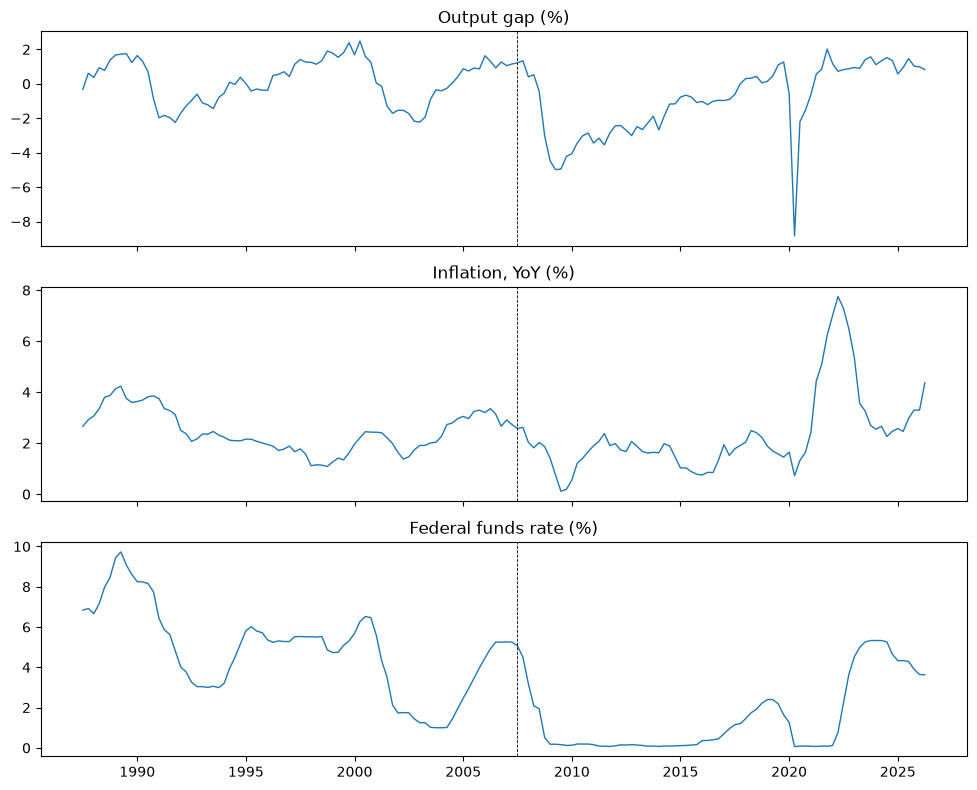

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, col, label in zip(axes, NAMES, ["Output gap (%)", "Inflation, YoY (%)", "Federal funds rate (%)"]):
    ax.plot(df_all.index.to_timestamp(), df_all[col], lw=1)
    ax.axvline(pd.Period(OOS_START, "Q").to_timestamp(), color="k", lw=0.6, ls="--")
    ax.set_title(label)
fig.tight_layout(); plt.show()

## Estimating the linear environment (recursive SVAR(2))

The paper estimates two equations by OLS with the recursive ordering imposed by including
contemporaneous $y_t$ in the inflation equation:

$$
y_t = C^y + a^{y\prime} s_t + \varepsilon^y_t,\qquad
\pi_t = C^\pi + a^\pi_{y,0}\,y_t + a^{\pi\prime} s_t + \varepsilon^\pi_t,\qquad
s_t = (y_{t-1}, y_{t-2}, \pi_{t-1}, \pi_{t-2}, i_{t-1}, i_{t-2}).
$$

That is the **structural form** of a recursively identified VAR. `cultivars` estimates the reduced form
with `VAR` and identifies the recursive structure with `RecursiveSVAR`; the two representations are
linked exactly by the Cholesky factor $B$ of the residual covariance:

$$
a^\pi_{y,0} = B_{\pi y} / B_{yy},\qquad
a^\pi_{\cdot} = \tilde a^\pi_{\cdot} - a^\pi_{y,0}\,\tilde a^y_{\cdot},
$$

where $\tilde a$ are reduced-form coefficients. The output-gap equation is identical in both forms
because $y$ is ordered first. The helper below performs that conversion so every table reads in the
paper's notation.

In [28]:
def structural_equations(var, svar) -> Dict[str, Dict[str, float]]:
    # Recursive structural-form coefficients (paper notation) from a fitted VAR and its Cholesky identification.
    B = svar.impact                                           # lower-triangular impact matrix, order y -> pi -> i
    red_y, red_pi = var.equation("y"), var.equation("pi")
    a_y0 = float(B[1, 0] / B[0, 0])                           # contemporaneous y in the pi equation
    struct_pi = {k: red_pi[k] - a_y0 * red_y[k] for k in red_pi}
    struct_pi = {"const": struct_pi.pop("const"), "y": a_y0, **struct_pi}
    return {"y": dict(red_y), "pi": struct_pi}

var  = VAR(df_train[NAMES].values, order=2, trend="c", names=NAMES).fit()
svar = RecursiveSVAR(var, order=NAMES).identify()

print(var.summary())
print(svar.summary())

                                 VAR(2) Results
Model:                          VAR(2)  Log-likelihood:                -32.300
Variables:                           3  AIC:                           118.600
Trend:                               c  BIC:                           182.231
Observations:                       78  HQIC:                          144.073
--------------------------------------------------------------------------------
                 coef   std err        z   P>|z|    [0.025    0.975]
y: const       0.2609    0.1911    1.365   0.172   -0.1136    0.6353
y: y.L1        1.0054    0.1275    7.887   0.000    0.7556    1.2553
y: pi.L1      -0.1594    0.3012   -0.529   0.597   -0.7498    0.4311
y: i.L1        0.2084    0.1628    1.280   0.201   -0.1107    0.5274
y: y.L2       -0.0955    0.1260   -0.758   0.448   -0.3425    0.1515
y: pi.L2       0.1105    0.3041    0.363   0.716   -0.4856    0.7066
y: i.L2       -0.2320    0.1518   -1.529   0.126   -0.5295    0.0655
pi:

### Restriction rule (post-estimation lag selection)

The paper drops second-lag terms whose p-value exceeds $\alpha = 0.10$ and refits. The `cultivars`
prerelease estimates the unrestricted system; equation-specific zero restrictions are not yet on its
public surface. The rule is therefore reported as a **diagnostic** -- which terms the paper's procedure
would zero out, using the reduced-form p-values that `VARResult` carries -- while the environment is
kept unrestricted. In the Bundesbank baseline the restriction changed no sign and no significant
coefficient; the reader can compare Table 9 below against the paper directly.

In [29]:
ALPHA_DROP = 0.10

def insignificant_lag2(var, equation: str, alpha: float = ALPHA_DROP) -> list[str]:
    return [k.split(": ", 1)[1] for k, p in var.pvalues.items()
            if k.startswith(f"{equation}: ") and k.endswith(".L2") and p > alpha]

for eq in ("y", "pi"):
    print(f"{eq} equation: lag-2 terms with p > {ALPHA_DROP}:", insignificant_lag2(var, eq) or "none")

y equation: lag-2 terms with p > 0.1: ['y.L2', 'pi.L2', 'i.L2']
pi equation: lag-2 terms with p > 0.1: ['i.L2']


### Substituted system

The estimated environment in the paper's notation, with the inflation equation in structural form.

In [30]:
coef = structural_equations(var, svar)

def render(eq: str, lhs: str) -> str:
    labels = {"const": "", "y": "y_t", "y.L1": "y_{t-1}", "y.L2": "y_{t-2}", "pi.L1": r"\pi_{t-1}",
              "pi.L2": r"\pi_{t-2}", "i.L1": "i_{t-1}", "i.L2": "i_{t-2}"}
    parts = []
    for k, v in coef[eq].items():
        term = f"{v:+.4f}{labels[k]}"
        parts.append(term)
    body = " ".join(parts).lstrip("+")
    return f"$${lhs} = {body}$$"

display(Markdown("**Output-gap equation**\n\n" + render("y", "y_t")))
display(Markdown("**Inflation equation (structural, recursive)**\n\n" + render("pi", r"\pi_t")))

**Output-gap equation**

$$y_t = 0.2609 +1.0054y_{t-1} -0.1594\pi_{t-1} +0.2084i_{t-1} -0.0955y_{t-2} +0.1105\pi_{t-2} -0.2320i_{t-2}$$

**Inflation equation (structural, recursive)**

$$\pi_t = 0.1353 -0.0739y_t +0.1907y_{t-1} +1.2331\pi_{t-1} +0.0562i_{t-1} -0.0936y_{t-2} -0.2631\pi_{t-2} -0.0705i_{t-2}$$

### Table 9 — SVAR estimates and diagnostics

Coefficients and p-values are the reduced-form estimates from `VARResult` (for the output-gap equation
these are the structural estimates; for inflation the structural coefficients are listed alongside).
The residual diagnostics replace Durbin–Watson and LM(1) with what `cultivars` reports for the system:
a multivariate portmanteau test on the lag order, Jarque–Bera normality per equation, and an
ARCH-LM test per equation.

In [31]:
rows = []
for eq in ("y", "pi"):
    for key, p in var.pvalues.items():
        if not key.startswith(f"{eq}: "):
            continue
        reg = key.split(": ", 1)[1]
        rows.append({"equation": eq, "regressor": reg, "reduced-form coef": var.params[key],
                     "std err": var.bse[key], "p-value": p, "structural coef": coef[eq].get(reg, np.nan)})
    if eq == "pi":
        rows.append({"equation": "pi", "regressor": "y (contemporaneous)", "reduced-form coef": np.nan,
                     "std err": np.nan, "p-value": np.nan, "structural coef": coef["pi"]["y"]})
table9 = pd.DataFrame(rows).set_index(["equation", "regressor"]).round(4)
display(table9)

sigma = np.sqrt(np.diag(var.sigma_u))
print("Residual std (y, pi, i):", np.round(sigma, 3))
print("Stable:", var.is_stable, "| observations:", var.nobs)
print(var.residual_diagnostics(portmanteau_lags=8, arch_lags=4))

reduced-form coef  std err  p-value  \
equation regressor                                                  
y        const                           0.2609   0.1911   0.1722   
         y.L1                            1.0054   0.1275   0.0000   
         pi.L1                          -0.1594   0.3012   0.5968   
         i.L1                            0.2084   0.1628   0.2005   
         y.L2                           -0.0955   0.1260   0.4484   
         pi.L2                           0.1105   0.3041   0.7163   
         i.L2                           -0.2320   0.1518   0.1263   
pi       const                           0.1160   0.0745   0.1193   
         y.L1                            0.1164   0.0497   0.0191   
         pi.L1                           1.2449   0.1174   0.0000   
         i.L1                            0.0408   0.0635   0.5198   
         y.L2                           -0.0866   0.0491   0.0781   
         pi.L2                          -0.2713   0.1186   0.0221   
         i.L2                           -0.0534   0.0592   0.3668   
         y (contemporaneous)                NaN      NaN      NaN   

                              structural coef  
equation regressor                             
y        const                         0.2609  
         y.L1                          1.0054  
         pi.L1                        -0.1594  
         i.L1                          0.2084  
         y.L2                         -0.0955  
         pi.L2                         0.1105  
         i.L2                         -0.2320  
pi       const                         0.1353  
         y.L1                          0.1907  
         pi.L1                         1.2331  
         i.L1                          0.0562  
         y.L2                         -0.0936  
         pi.L2                        -0.2631  
         i.L2                         -0.0705  
         y (contemporaneous)          -0.0739

Residual std (y, pi, i): [0.478 0.186 0.311]
Stable: True | observations: 78
                              Residual diagnostics
Observations:                       78  Equations:                           3
--------------------------------------------------------------------------------
test                statistic   df   p-value
portmanteau(8)         57.848   51    0.2372
jarque-bera[y]          1.059    2    0.5890
jarque-bera[pi]         2.130    2    0.3447
jarque-bera[i]          1.120    2    0.5712
arch-lm(4)[y]           1.054    4    0.9015
arch-lm(4)[pi]          1.904    4    0.7534
arch-lm(4)[i]           8.643    4    0.0707
Small p-values reject the null named by each test. A rejected portmanteau means
the lag order is too short, which invalidates every other quantity the result
reports.


### Impulse responses of the environment

A policy-learning agent acts through $i_t$; the recursive SVAR says how the environment answers. The
responses below are to a one-standard-deviation structural shock to the policy rate under the ordering
$y \to \pi \to i$ (the rate reacts to output and prices within the quarter; they react to the rate with
a lag). This is the identifying assumption, stated as such in the `RecursiveSVAR` summary.

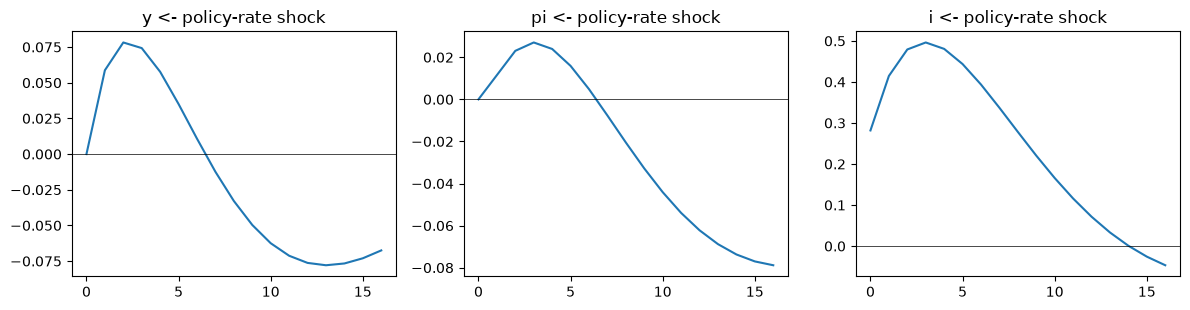

In [32]:
irf = svar.irf(horizon=16)                       # (horizon + 1, variable, shock)
h = np.arange(irf.shape[0])
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for k, name in enumerate(NAMES):
    axes[k].plot(h, irf[:, k, 2]); axes[k].axhline(0, color="k", lw=0.5)
    axes[k].set_title(f"{name} <- policy-rate shock")
fig.tight_layout(); plt.show()

## Out-of-sample comparison: fitted linear environment vs. realized data

Forecasts use the **training-sample coefficients** and **realized lagged values** as inputs (one-step
mapping, no recursive feedback). The inflation fitted value is **conditional on realized $y_t$**, as in
the paper: under the recursive ordering that equals the reduced-form one-step forecast plus
$a^\pi_{y,0}\,(y_t - \hat y_t)$, which is what `cultivars.forecast.conditional_forecast` computes in
general; here the one-step closed form is used directly.

In [33]:
def one_step(var, svar, frame: pd.DataFrame, start: str) -> pd.DataFrame:
    # One-step fitted (y, pi) from `start` on, with realized lags and pi conditional on realized y_t.
    A = var.coefficients                                       # (order, k, k): A[l][row=equation, col=lagged variable]
    c = np.asarray(var.deterministic)[0]                      # constants, one per equation
    a_y0 = float(svar.impact[1, 0] / svar.impact[0, 0])
    X = frame[NAMES].to_numpy()
    out = pd.DataFrame(index=frame.index, columns=["y_hat", "pi_hat"], dtype=float)
    first = max(frame.index.get_loc(pd.Period(start, "Q")), var.order)
    for t in range(first, len(frame)):
        pred = c + sum(A[l] @ X[t - 1 - l] for l in range(var.order))
        out.iloc[t, 0] = pred[0]
        out.iloc[t, 1] = pred[1] + a_y0 * (X[t, 0] - pred[0])   # conditional on realized y_t
    return out

fixed = one_step(var, svar, df_all, OOS_START)
df_fixed = df_all.join(fixed)
oos_fixed = df_fixed.loc[OOS_START:].dropna()

for col in ("y", "pi"):
    e = oos_fixed[col] - oos_fixed[f"{col}_hat"]
    print(f"OOS fixed-coefficient SVAR(2) | {col}: MSE={np.mean(e**2):.4f}, RMSE={np.sqrt(np.mean(e**2)):.4f}, n={len(e)}")

OOS fixed-coefficient SVAR(2) | y: MSE=1.8062, RMSE=1.3440, n=76
OOS fixed-coefficient SVAR(2) | pi: MSE=0.3004, RMSE=0.5481, n=76


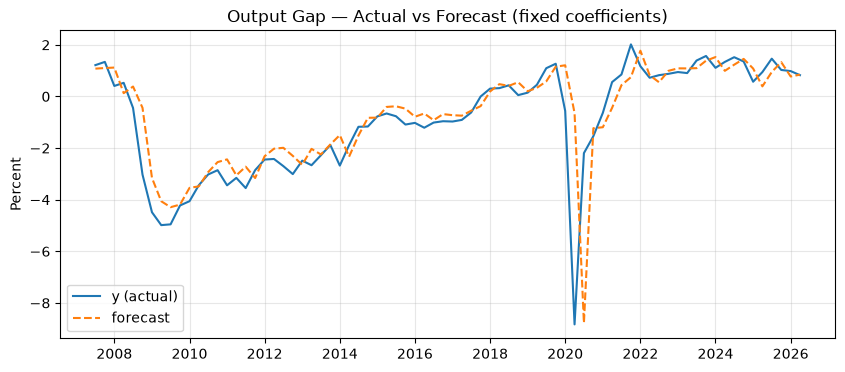

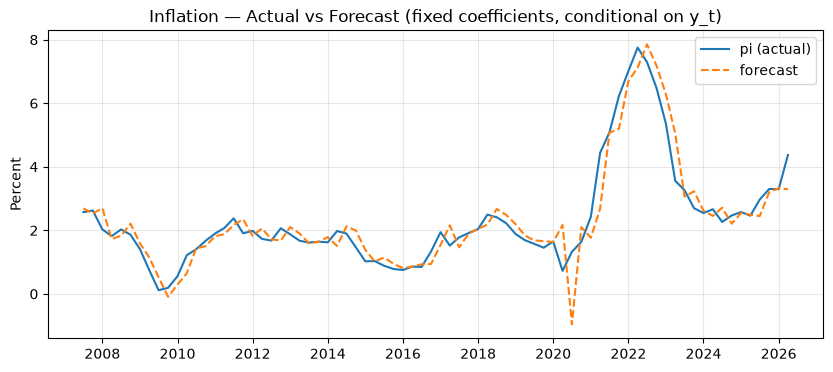

In [34]:
def plot_actual_vs_fit(frame: pd.DataFrame, col: str, fit_col: str, title: str, fit_label: str):
    fig, ax = plt.subplots()
    ax.plot(frame.index.to_timestamp(), frame[col], label=f"{col} (actual)")
    ax.plot(frame.index.to_timestamp(), frame[fit_col], "--", label=fit_label)
    ax.set_title(title); ax.set_ylabel("Percent"); ax.grid(True, alpha=0.3); ax.legend()
    plt.show()

plot_actual_vs_fit(oos_fixed, "y",  "y_hat",  "Output Gap — Actual vs Forecast (fixed coefficients)", "forecast")
plot_actual_vs_fit(oos_fixed, "pi", "pi_hat", "Inflation — Actual vs Forecast (fixed coefficients, conditional on y_t)", "forecast")

## In-sample fit and error diagnostics

Squared one-step errors over the training window (Figures 4 and 5 of the paper).

In-sample std(resid): 0.456 0.175


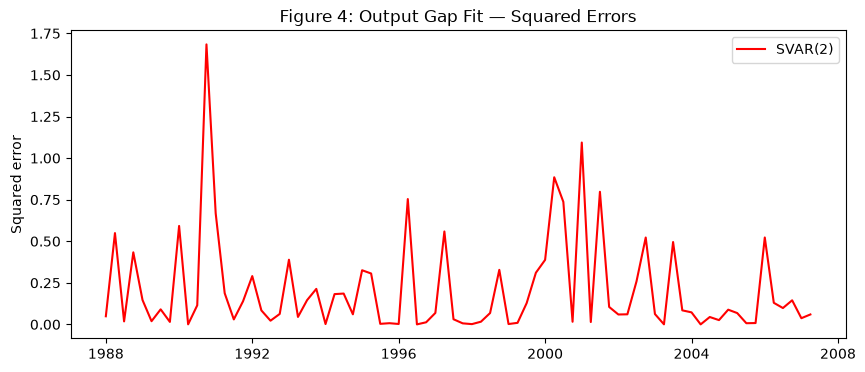

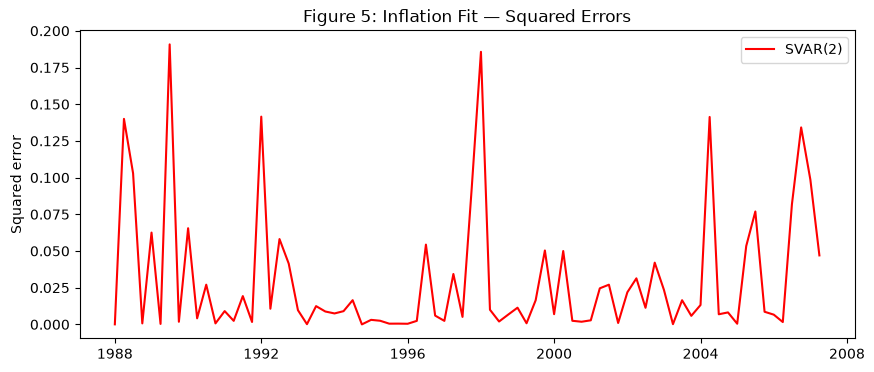

In [35]:
fit_is = one_step(var, svar, df_train, TRAIN_START)
fit_is = df_train.join(fit_is).dropna()
fit_is["se_y_svar"]  = (fit_is["y"]  - fit_is["y_hat"])  ** 2
fit_is["se_pi_svar"] = (fit_is["pi"] - fit_is["pi_hat"]) ** 2
print("In-sample std(resid):", round(np.sqrt(fit_is["se_y_svar"].mean()), 3), round(np.sqrt(fit_is["se_pi_svar"].mean()), 3))

def plot_se(frame, col, title):
    fig, ax = plt.subplots()
    ax.plot(frame.index.to_timestamp(), frame[col], color="red", lw=1.5, label="SVAR(2)")
    ax.set_title(title); ax.set_ylabel("Squared error"); ax.legend(); plt.show()

plot_se(fit_is, "se_y_svar",  "Figure 4: Output Gap Fit — Squared Errors")
plot_se(fit_is, "se_pi_svar", "Figure 5: Inflation Fit — Squared Errors")

--------

# Alternative Specification: Rolling-Window SVAR(2)

The recursive SVAR(2) is re-estimated on a trailing window of $W$ quarters before every forecast
quarter, with one-step fitted values from realized lags and inflation conditional on realized $y_t$.
This is the standard device for suspected parameter instability (Clements & Hendry, 1998; Stock &
Watson, 2007).

**On the window length.** The original notebook used $W = 4$. Each equation has seven regressors and a
two-lag VAR loses two rows to lags, so a four-quarter window leaves two observations for seven
coefficients: the OLS problem is rank-deficient, and any fitted values it produces are artefacts of the
pseudo-inverse. `cultivars` refuses that specification (it needs at least $kp + 1 + k = 10$ rows, and in
practice more). This notebook uses $W = 40$ quarters (ten years) and states the minimum in the code;
lower it to see estimation noise grow.

In [36]:
W = 40                                         # rolling window, quarters
assert W >= 12, "VAR(2) in three variables needs at least 12 rows to be estimated from data alone"

def rolling_one_step(frame: pd.DataFrame, window: int, start: str) -> pd.DataFrame:
    out = pd.DataFrame(index=frame.index, columns=["y_hat", "pi_hat"], dtype=float)
    X = frame[NAMES].to_numpy()
    first = max(frame.index.get_loc(pd.Period(start, "Q")), window)
    for t in range(first, len(frame)):
        sample = X[t - window : t]
        v = VAR(sample, order=2, trend="c", names=NAMES).fit()
        s = RecursiveSVAR(v, order=NAMES).identify()
        c = np.asarray(v.deterministic)[0]
        pred = c + sum(v.coefficients[l] @ X[t - 1 - l] for l in range(2))
        a_y0 = float(s.impact[1, 0] / s.impact[0, 0])
        out.iloc[t, 0] = pred[0]
        out.iloc[t, 1] = pred[1] + a_y0 * (X[t, 0] - pred[0])
    return out

roll_is  = df_train.join(rolling_one_step(df_train, W, TRAIN_START)).dropna()
roll_all = df_all.join(rolling_one_step(df_all, W, TRAIN_START))
roll_oos = roll_all.loc[OOS_START:].dropna()

for label, frame in (("in-sample", roll_is), ("OOS", roll_oos)):
    for col in ("y", "pi"):
        e = frame[col] - frame[f"{col}_hat"]
        print(f"{label:9s} rolling W={W} | {col}: MSE={np.mean(e**2):.4f}, RMSE={np.sqrt(np.mean(e**2)):.4f}, n={len(e)}")

in-sample rolling W=40 | y: MSE=0.3363, RMSE=0.5799, n=40
in-sample rolling W=40 | pi: MSE=0.0426, RMSE=0.2063, n=40
OOS       rolling W=40 | y: MSE=7.8952, RMSE=2.8098, n=76
OOS       rolling W=40 | pi: MSE=0.2665, RMSE=0.5162, n=76


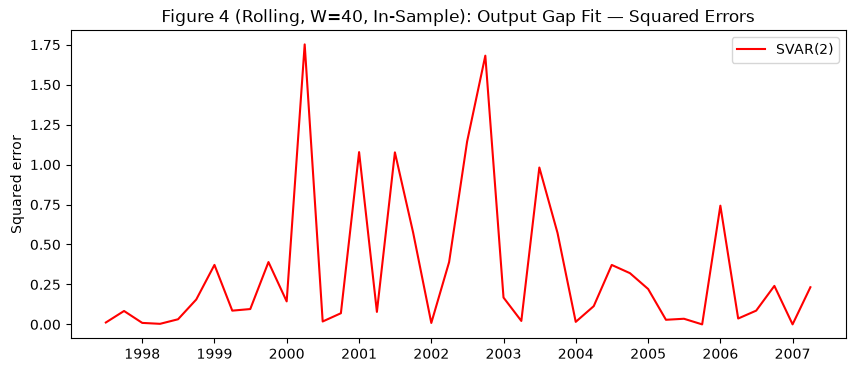

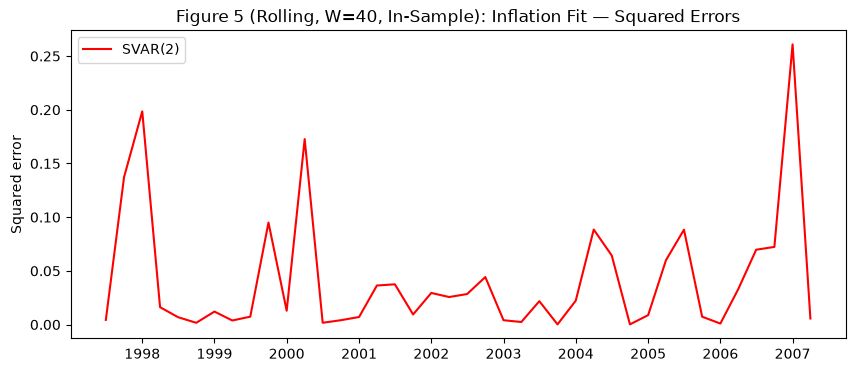

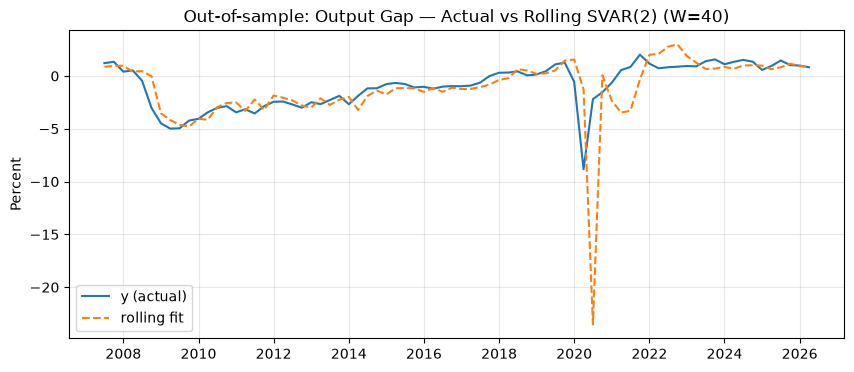

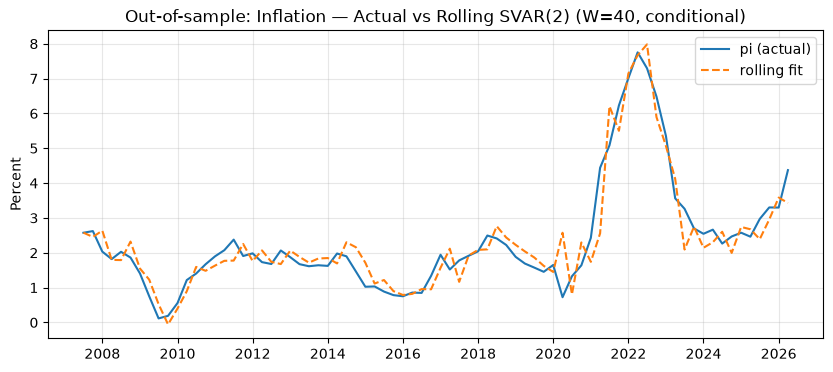

In [37]:
roll_is["se_y"]  = (roll_is["y"]  - roll_is["y_hat"])  ** 2
roll_is["se_pi"] = (roll_is["pi"] - roll_is["pi_hat"]) ** 2
plot_se(roll_is, "se_y",  f"Figure 4 (Rolling, W={W}, In-Sample): Output Gap Fit — Squared Errors")
plot_se(roll_is, "se_pi", f"Figure 5 (Rolling, W={W}, In-Sample): Inflation Fit — Squared Errors")
plot_actual_vs_fit(roll_oos, "y",  "y_hat",  f"Out-of-sample: Output Gap — Actual vs Rolling SVAR(2) (W={W})", "rolling fit")
plot_actual_vs_fit(roll_oos, "pi", "pi_hat", f"Out-of-sample: Inflation — Actual vs Rolling SVAR(2) (W={W}, conditional)", "rolling fit")

--------

# Modified Alternative Specification: Expanding-Window SVAR(2)

Same system, re-estimated every quarter on all data from 1987Q3 through $t-1$ (recursive estimation in
the sense of Hamilton, 1994). The information set grows monotonically; no observation is discarded.

in-sample expanding | y: MSE=0.5066, RMSE=0.7118, n=68
in-sample expanding | pi: MSE=0.0726, RMSE=0.2695, n=68
OOS       expanding | y: MSE=2.8294, RMSE=1.6821, n=76
OOS       expanding | pi: MSE=0.2283, RMSE=0.4778, n=76


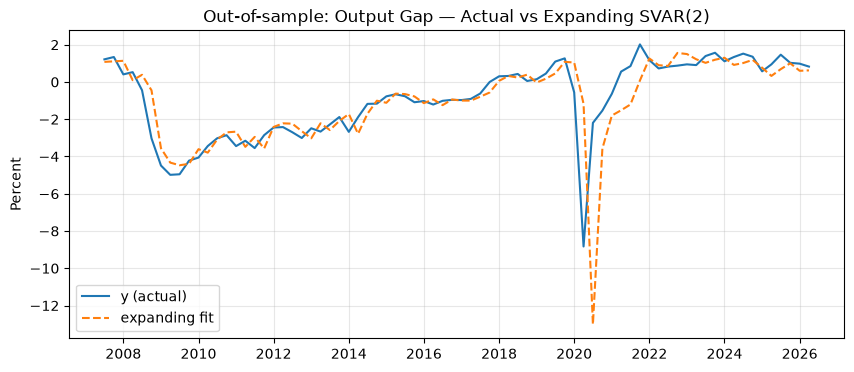

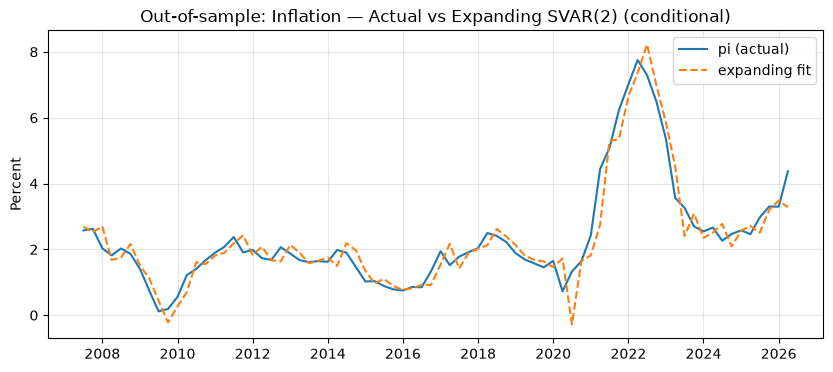

In [38]:
MIN_EXPANDING = 12

def expanding_one_step(frame: pd.DataFrame, start: str, minimum: int = MIN_EXPANDING) -> pd.DataFrame:
    out = pd.DataFrame(index=frame.index, columns=["y_hat", "pi_hat"], dtype=float)
    X = frame[NAMES].to_numpy()
    first = max(frame.index.get_loc(pd.Period(start, "Q")), minimum)
    for t in range(first, len(frame)):
        v = VAR(X[:t], order=2, trend="c", names=NAMES).fit()
        s = RecursiveSVAR(v, order=NAMES).identify()
        c = np.asarray(v.deterministic)[0]
        pred = c + sum(v.coefficients[l] @ X[t - 1 - l] for l in range(2))
        a_y0 = float(s.impact[1, 0] / s.impact[0, 0])
        out.iloc[t, 0] = pred[0]
        out.iloc[t, 1] = pred[1] + a_y0 * (X[t, 0] - pred[0])
    return out

exp_all = df_all.join(expanding_one_step(df_all, TRAIN_START))
exp_is  = exp_all.loc[:TRAIN_END].dropna()
exp_oos = exp_all.loc[OOS_START:].dropna()

for label, frame in (("in-sample", exp_is), ("OOS", exp_oos)):
    for col in ("y", "pi"):
        e = frame[col] - frame[f"{col}_hat"]
        print(f"{label:9s} expanding | {col}: MSE={np.mean(e**2):.4f}, RMSE={np.sqrt(np.mean(e**2)):.4f}, n={len(e)}")

plot_actual_vs_fit(exp_oos, "y",  "y_hat",  "Out-of-sample: Output Gap — Actual vs Expanding SVAR(2)", "expanding fit")
plot_actual_vs_fit(exp_oos, "pi", "pi_hat", "Out-of-sample: Inflation — Actual vs Expanding SVAR(2) (conditional)", "expanding fit")

## Formal comparison of the re-estimation schemes

The paper's comparison is descriptive (MSE by eye). `cultivars.forecast.Backtest` runs the same rolling
and expanding exercises as a formal out-of-sample evaluation, re-estimating the (unconditional)
reduced-form VAR at every origin from 2007Q3, and `ForecastComparison` tests the loss differential with
Diebold–Mariano, its Harvey–Leybourne–Newbold correction (the one to read on a window this short) and
the Giacomini–White conditional test. The comparison is on the output gap at horizon one, where the
conditional-versus-unconditional distinction does not arise.

In [39]:
start_index = df_all.index.get_loc(pd.Period(OOS_START, "Q"))
fit_var = lambda x: VAR(x, order=2, trend="c", names=NAMES).fit()

bt_rolling   = Backtest(df_all[NAMES].values, fit_var, horizons=1, start=start_index, scheme="rolling", window=W, names=NAMES).run()
bt_expanding = Backtest(df_all[NAMES].values, fit_var, horizons=1, start=start_index, scheme="expanding", names=NAMES).run()
print(bt_expanding.summary())

la = bt_rolling.losses("squared", horizon=1, name="y")
lb = bt_expanding.losses("squared", horizon=1, name="y")
print(ForecastComparison(la, lb).compute(horizon=1).summary())

                                    Backtest
Origins:                            76  Horizons:                            1
Series:                              3  Scheme:                      expanding
Draws:                               0
--------------------------------------------------------------------------------
h     series     RMSE      MAE   mean CRPS
1          y   1.6821   0.7302           -
1         pi   0.5204   0.3574           -
1          i   0.4104   0.2275           -
Expanding scheme, 76 origins 1 apart, re-estimated at every origin; first
estimation on 80 observations.
Row t's h-step forecast is aligned with the outcome at origins[t] + h - 1;
losses(kind, horizon=h, name=...) hands the aligned series to a comparison test.
Point forecasts only: CRPS, log scores, and calibration need a result exposing
forecast_paths().
                              Forecast Comparison
Origins:                            76  Horizon:                             1
Mean differential:

--------

# Modern Specification: TVP-SVAR with Stochastic Volatility

The fixed-parameter environment is replaced by Primiceri's (2005) **time-varying-parameter VAR with
stochastic volatility**. Coefficients follow random walks, log innovation variances follow random walks,
and the same triangular ordering $y \to \pi \to i$ identifies the contemporaneous relations. Where the
original notebook fitted two univariate TVP regressions with PyMC (ADVI initialisation, then NUTS),
`cultivars.multivariate.TVPVARSV` estimates the **joint system** by the Gibbs sampler of Primiceri, with
the Kim–Shephard–Chib mixture block for the volatilities.

The prior is calibrated on a **training sample** (Primiceri's convention): the forty quarters before
1987Q3, which are then discarded, so every posterior path below is indexed on 1987Q3 onward -- the same
sample as the baseline. `k_drift` and `k_vol` are Primiceri's $k_Q$ and $k_W$.

In [40]:
tvp = TVPVARSV(df_tvp[NAMES].values, order=2, training=TVP_TRAINING_QUARTERS, trend="c", names=NAMES).fit(
    n_draws=3000, n_burn=1500, thin=2, k_drift=0.01, k_vol=0.01, seed=123
)
print(tvp.summary())

tvp_index = df_tvp.index[TVP_TRAINING_QUARTERS + tvp.order:][: tvp.nobs]
assert len(tvp_index) == tvp.nobs and tvp_index[0] == pd.Period(TRAIN_START, "Q")

                               TVP-VAR-SV(2) Results
Model:                      TVP-VAR-SV(2)  Draws:           3000 (1500 burn, thin 2)
Variables:                              3  Kept:                                 750
Observations:                         156  Training:                              40
Trend:                                  c  State dimension:                       21
------------------------------------------------------------------------------------
equation     own L1 at start   own L1 at end
y                     0.9896          0.9789
pi                    1.3631          1.3671
i                     1.5488          1.5716
Posterior mean drift over the sample: max |beta_T - beta_1| = 0.1780 against a
median 68% band width of 0.1378; drift smaller than the band is not evidence of time
variation.
Max |companion root| of the posterior mean path: 0.9348 (a drifting model may pass
through locally explosive dates; stability_path() shows where).
The training sample 

## Fitted paths and squared errors

`fittedvalues` is the posterior-mean conditional mean $X_t\beta_t$ at every date. The inflation fit is
made conditional on realized $y_t$ exactly as before, using the posterior-mean contemporaneous
coefficient implied by the (time-invariant) triangular factor $A$.

in-sample TVP-SVAR-SV | y: MSE=0.2194, RMSE=0.4684, n=80
in-sample TVP-SVAR-SV | pi: MSE=0.0350, RMSE=0.1870, n=80
OOS       TVP-SVAR-SV | y: MSE=1.7685, RMSE=1.3298, n=76
OOS       TVP-SVAR-SV | pi: MSE=0.1953, RMSE=0.4419, n=76


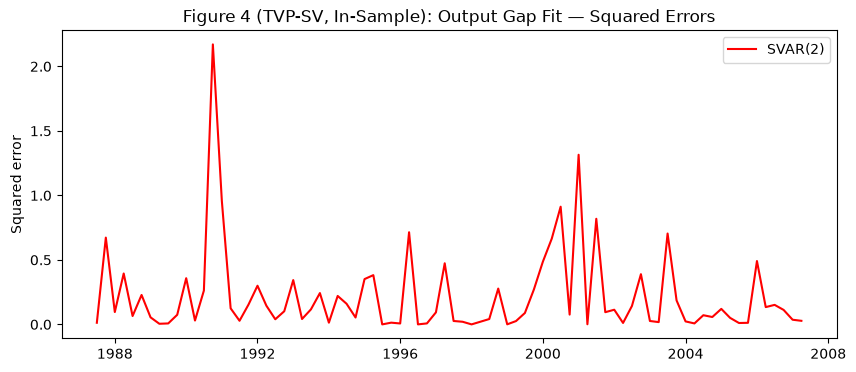

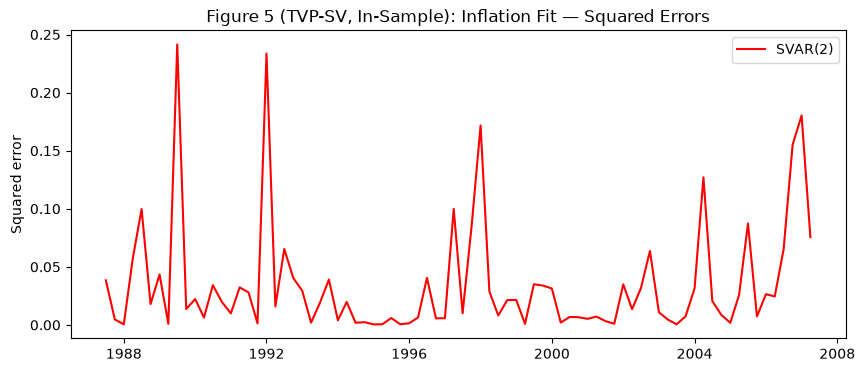

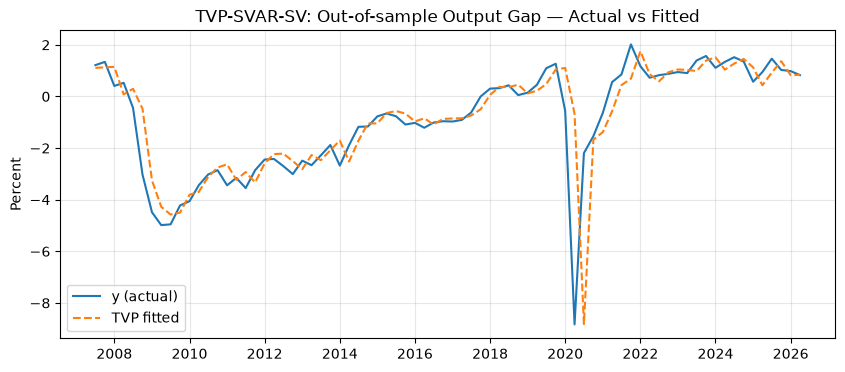

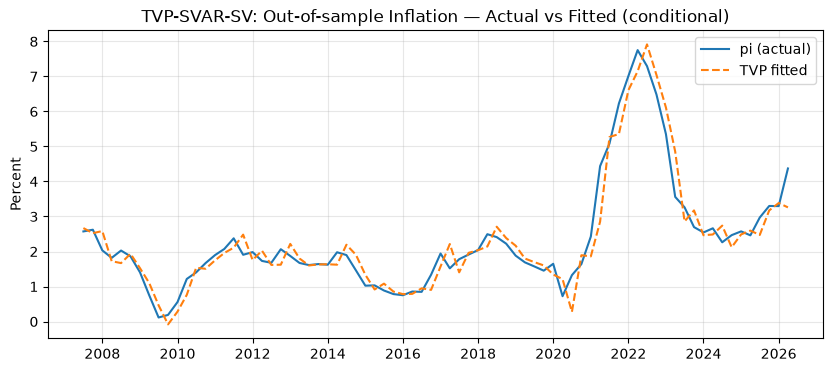

In [41]:
B_draws = tvp.impact_draws                                   # (draws, k, k) lower-triangular impact
a_y0_tvp = float(np.mean(B_draws[:, 1, 0] / B_draws[:, 0, 0]))

fit_tvp = pd.DataFrame(tvp.fittedvalues, index=tvp_index, columns=[f"{n}_hat" for n in NAMES])
fit_tvp = df_tvp.loc[tvp_index, NAMES].join(fit_tvp)
fit_tvp["pi_hat"] = fit_tvp["pi_hat"] + a_y0_tvp * (fit_tvp["y"] - fit_tvp["y_hat"])

for label, frame in (("in-sample", fit_tvp.loc[TRAIN_START:TRAIN_END]), ("OOS", fit_tvp.loc[OOS_START:])):
    for col in ("y", "pi"):
        e = frame[col] - frame[f"{col}_hat"]
        print(f"{label:9s} TVP-SVAR-SV | {col}: MSE={np.mean(e**2):.4f}, RMSE={np.sqrt(np.mean(e**2)):.4f}, n={len(e)}")

tvp_is = fit_tvp.loc[TRAIN_START:TRAIN_END].copy()
tvp_is["se_y"]  = (tvp_is["y"]  - tvp_is["y_hat"])  ** 2
tvp_is["se_pi"] = (tvp_is["pi"] - tvp_is["pi_hat"]) ** 2
plot_se(tvp_is, "se_y",  "Figure 4 (TVP-SV, In-Sample): Output Gap Fit — Squared Errors")
plot_se(tvp_is, "se_pi", "Figure 5 (TVP-SV, In-Sample): Inflation Fit — Squared Errors")

tvp_oos = fit_tvp.loc[OOS_START:]
plot_actual_vs_fit(tvp_oos, "y",  "y_hat",  "TVP-SVAR-SV: Out-of-sample Output Gap — Actual vs Fitted", "TVP fitted")
plot_actual_vs_fit(tvp_oos, "pi", "pi_hat", "TVP-SVAR-SV: Out-of-sample Inflation — Actual vs Fitted (conditional)", "TVP fitted")

## What the TVP model adds: drift and volatility

Two things a fixed-coefficient environment cannot show. First, the posterior path of a coefficient with
its 68% band -- here the own-lag persistence of inflation and the response of the output gap to the
lagged policy rate. Second, the innovation standard deviation of each equation over time: the Great
Moderation, the crisis, and 2020 are visible as volatility, not as coefficient change.

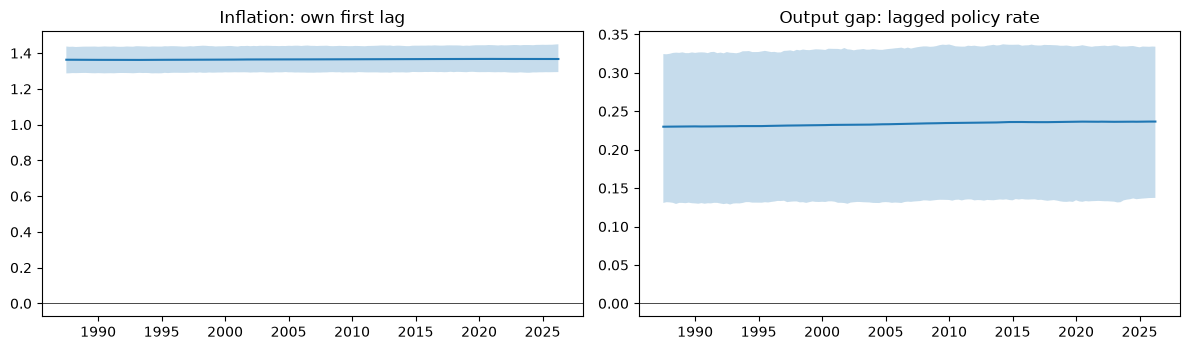

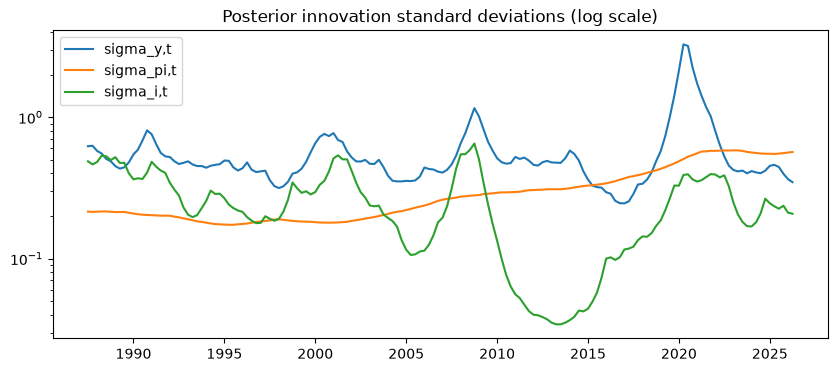

In [42]:
dates = tvp_index.to_timestamp()
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, (eq, reg, title) in zip(axes, [("pi", "pi.L1", "Inflation: own first lag"), ("y", "i.L1", "Output gap: lagged policy rate")]):
    low, mean, high = tvp.coefficient_path(eq, reg).T
    ax.fill_between(dates, low, high, alpha=0.25); ax.plot(dates, mean)
    ax.axhline(0, color="k", lw=0.5); ax.set_title(title)
fig.tight_layout(); plt.show()

fig, ax = plt.subplots()
for name in NAMES:
    low, mean, high = tvp.volatility_path(name).T
    ax.plot(dates, mean, label=f"sigma_{name},t")
ax.set_yscale("log"); ax.set_title("Posterior innovation standard deviations (log scale)"); ax.legend()
plt.show()

--------

# Summary of out-of-sample performance

One-step RMSE from 2007Q3 across the four environments. All use realized lags and inflation
conditional on realized $y_t$; the TVP figure is a smoothed (two-sided) fit rather than a real-time
forecast and is therefore not on the same footing as the other three.

In [43]:
def rmse(frame, col): return float(np.sqrt(np.mean((frame[col] - frame[f"{col}_hat"]) ** 2)))
summary = pd.DataFrame({
    "fixed (1987Q3-2007Q2)": {"y": rmse(oos_fixed, "y"), "pi": rmse(oos_fixed, "pi")},
    f"rolling W={W}":        {"y": rmse(roll_oos, "y"),  "pi": rmse(roll_oos, "pi")},
    "expanding":             {"y": rmse(exp_oos, "y"),   "pi": rmse(exp_oos, "pi")},
    "TVP-SVAR-SV (smoothed)":{"y": rmse(tvp_oos, "y"),   "pi": rmse(tvp_oos, "pi")},
}).T.round(4)
summary.columns = ["RMSE y", "RMSE pi"]
display(summary)

,RMSE y,RMSE pi
fixed (1987Q3-2007Q2),1.3440,0.5481
rolling W=40,2.8098,0.5162
expanding,1.6821,0.4778
TVP-SVAR-SV (smoothed),1.3298,0.4419


--------

# References (APA)

## Software

1. Sunder, N. (2026). cultivars: Research-grade time series econometrics for Python (v1.0.0a1). https://pypi.org/project/cultivars/
2. Sunder, N. (2025). fedfred: A Python client for the Federal Reserve Economic Database (FRED) API (v3.0.0). Zenodo. https://doi.org/10.5281/zenodo.17635942
3. The pandas development team. (2026). pandas-dev/pandas: Pandas. Zenodo. https://doi.org/10.5281/zenodo.18675244
4. Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585(7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2
5. Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
6. The Matplotlib Development Team. (2025). Matplotlib: Visualization with Python. Zenodo. https://doi.org/10.5281/zenodo.17595503

## Papers & Books

1. Hinterlang, N., & Tänzer, A. (2021). Optimal monetary policy using reinforcement learning. *SSRN*. https://doi.org/10.2139/ssrn.4013384
2. Sims, C. A. (1980). Macroeconomics and reality. *Econometrica*, 48(1), 1–48. https://doi.org/10.2307/1912017
3. Lütkepohl, H. (2005). *New introduction to multiple time series analysis*. Springer.
4. Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.
5. Primiceri, G. E. (2005). Time varying structural vector autoregressions and monetary policy. *Review of Economic Studies*, 72(3), 821–852.
6. Cogley, T., & Sargent, T. J. (2005). Drifts and volatilities: Monetary policies and outcomes in the post WWII US. *Review of Economic Dynamics*, 8(2), 262–302.
7. Kim, S., Shephard, N., & Chib, S. (1998). Stochastic volatility: Likelihood inference and comparison with ARCH models. *Review of Economic Studies*, 65(3), 361–393.
8. Diebold, F. X., & Mariano, R. S. (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263.
9. Harvey, D., Leybourne, S., & Newbold, P. (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291.
10. Giacomini, R., & White, H. (2006). Tests of conditional predictive ability. *Econometrica*, 74(6), 1545–1578.
11. Clements, M. P., & Hendry, D. F. (1998). *Forecasting economic time series*. Cambridge University Press.
12. Stock, J. H., & Watson, M. W. (2007). Why has U.S. inflation become harder to forecast? *Journal of Money, Credit and Banking*, 39(s1), 3–33.